<div style="background-color:#d40457; padding:15px; border-radius:10px;">
    <h1 style="color:white; margin:0;">Water Quality Analysis</h1>
</div>

<br>

<h3>Tujuan</h3>
<p>
Menganalisis parameter kualitas air dan memprediksi apakah air <b>layak diminum (potable)</b> atau <b>tidak layak diminum (not potable)</b> berdasarkan karakteristik fisikokimia air.
</p>

<h3>Dataset</h3>
<p>
Dataset yang digunakan adalah <b>Water Potability Dataset</b> dari Kaggle yang berisi berbagai parameter kualitas air seperti pH, hardness, solids, chloramines, sulfate, dan lainnya.
</p>

<p>
<a href="https://www.kaggle.com/datasets/adityakadiwal/water-potability" target="_blank">
https://www.kaggle.com/datasets/adityakadiwal/water-potability
</a>
</p>

In [1]:
# Impor library
import warnings
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score, RandomizedSearchCV
from sklearn.preprocessing import RobustScaler
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier, ExtraTreesClassifier
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    roc_auc_score, roc_curve, confusion_matrix, classification_report,
    precision_recall_curve, average_precision_score
)

import xgboost as xgb
import lightgbm as lgb
import shap
import kagglehub

print("Library berhasil diimpor.")

Library berhasil diimpor.


In [2]:
# Konfigurasi tampilan
warnings.filterwarnings("ignore")
pd.set_option("display.max_columns", None)
pd.set_option("display.float_format", "{:.4f}".format)
sns.set_theme(style="whitegrid", palette="muted")
plt.rcParams.update({"figure.dpi": 120, "axes.titlesize": 13, "axes.labelsize": 11})

# Konstanta global
RANDOM_STATE = 42
WARNA_KELAS = {"Tidak Layak": "#e07b54", "Layak Minum": "#5b8db8"}

print("Lingkungan berhasil dikonfigurasi.")

Lingkungan berhasil dikonfigurasi.


<div style="background-color:#d40457; padding:15px; border-radius:10px;">
    <h1 style="color:white; margin:0;">Dataset</h1>
</div>

In [3]:
# Path ke dataset lokal
path = "D:/A11.2025.16609/SEMESTER 2/PEMBELAJARAN MESIN - A11.4405/project/"
df = pd.read_csv(os.path.join(path, "water_potability.csv"))

print("Dataset berhasil dimuat.")

Dataset berhasil dimuat.


In [4]:
# Menampilkan 5 baris pertama dataset
df.head()

,ph,Hardness,Solids,Chloramines,Sulfate,Conductivity,Organic_carbon,Trihalomethanes,Turbidity,Potability
0,NaN,204.8905,20791.3190,7.3002,368.5164,564.3087,10.3798,86.9910,2.9631,0
1,3.7161,129.4229,18630.0579,6.6352,NaN,592.8854,15.1800,56.3291,4.5007,0
2,8.0991,224.2363,19909.5417,9.2759,NaN,418.6062,16.8686,66.4201,3.0559,0
3,8.3168,214.3734,22018.4174,8.0593,356.8861,363.2665,18.4365,100.3417,4.6288,0
4,9.0922,181.1015,17978.9863,6.5466,310.1357,398.4108,11.5583,31.9980,4.0751,0


In [5]:
# Menampilkan ringkasan dataset secara terstruktur
def dataset_summary(dataframe):
    """Menampilkan ringkasan terstruktur dataset: dimensi, tipe data, nilai kosong, dan duplikat."""
    print("=" * 75)
    print("RINGKASAN DATASET")
    print("=" * 75)
    print(f"Jumlah Baris        : {dataframe.shape[0]}")
    print(f"Jumlah Kolom        : {dataframe.shape[1]}")
    print(f"Baris Duplikat      : {dataframe.duplicated().sum()}")
    print(f"Total Nilai Kosong  : {dataframe.isnull().sum().sum()}")
    print()
    print("-" * 75)
    print("INFORMASI KOLOM")
    print("-" * 75)
    info_df = pd.DataFrame({
        "Tipe Data": dataframe.dtypes,
        "Jumlah Kosong": dataframe.isnull().sum(),
        "Persen Kosong (%)": (dataframe.isnull().sum() / len(dataframe) * 100).round(2),
        "Nilai Unik": dataframe.nunique()
    })
    print(info_df.to_string())
    print("=" * 75)

dataset_summary(df)

RINGKASAN DATASET
Jumlah Baris        : 3276
Jumlah Kolom        : 10
Baris Duplikat      : 0
Total Nilai Kosong  : 1434

---------------------------------------------------------------------------
INFORMASI KOLOM
---------------------------------------------------------------------------
                Tipe Data  Jumlah Kosong  Persen Kosong (%)  Nilai Unik
ph                float64            491            14.9900        2785
Hardness          float64              0             0.0000        3276
Solids            float64              0             0.0000        3276
Chloramines       float64              0             0.0000        3276
Sulfate           float64            781            23.8400        2495
Conductivity      float64              0             0.0000        3276
Organic_carbon    float64              0             0.0000        3276
Trihalomethanes   float64            162             4.9500        3114
Turbidity         float64              0             0.0000   

In [6]:
# Menampilkan statistik deskriptif untuk kolom numerik
df.describe().T

,count,mean,std,min,25%,50%,75%,max
ph,2785.0000,7.0808,1.5943,0.0000,6.0931,7.0368,8.0621,14.0000
Hardness,3276.0000,196.3695,32.8798,47.4320,176.8505,196.9676,216.6675,323.1240
Solids,3276.0000,22014.0925,8768.5708,320.9426,15666.6903,20927.8336,27332.7621,61227.1960
Chloramines,3276.0000,7.1223,1.5831,0.3520,6.1274,7.1303,8.1149,13.1270
Sulfate,2495.0000,333.7758,41.4168,129.0000,307.6995,333.0735,359.9502,481.0306
Conductivity,3276.0000,426.2051,80.8241,181.4838,365.7344,421.8850,481.7923,753.3426
Organic_carbon,3276.0000,14.2850,3.3082,2.2000,12.0658,14.2183,16.5577,28.3000
Trihalomethanes,3114.0000,66.3963,16.1750,0.7380,55.8445,66.6225,77.3375,124.0000
Turbidity,3276.0000,3.9668,0.7804,1.4500,3.4397,3.9550,4.5003,6.7390
Potability,3276.0000,0.3901,0.4878,0.0000,0.0000,0.0000,1.0000,1.0000


<div style="background-color:#d40457; padding:15px; border-radius:10px;">
    <h1 style="color:white; margin:0;">Exploratory Data Analysis (EDA)</h1>
</div>

### 1. Distribusi Target Variable (Potability)

Pada bagian ini, kita akan menganalisis distribusi kelas target `Potability`:
- **Kelas 0**: Air tidak layak minum
- **Kelas 1**: Air layak minum

Visualisasi ini penting untuk:
- Memahami apakah dataset seimbang (*balanced*) atau tidak seimbang (*imbalanced*)
- Menentukan strategi handling class imbalance jika diperlukan
- Memberikan insight tentang komposisi dataset yang akan digunakan untuk training model

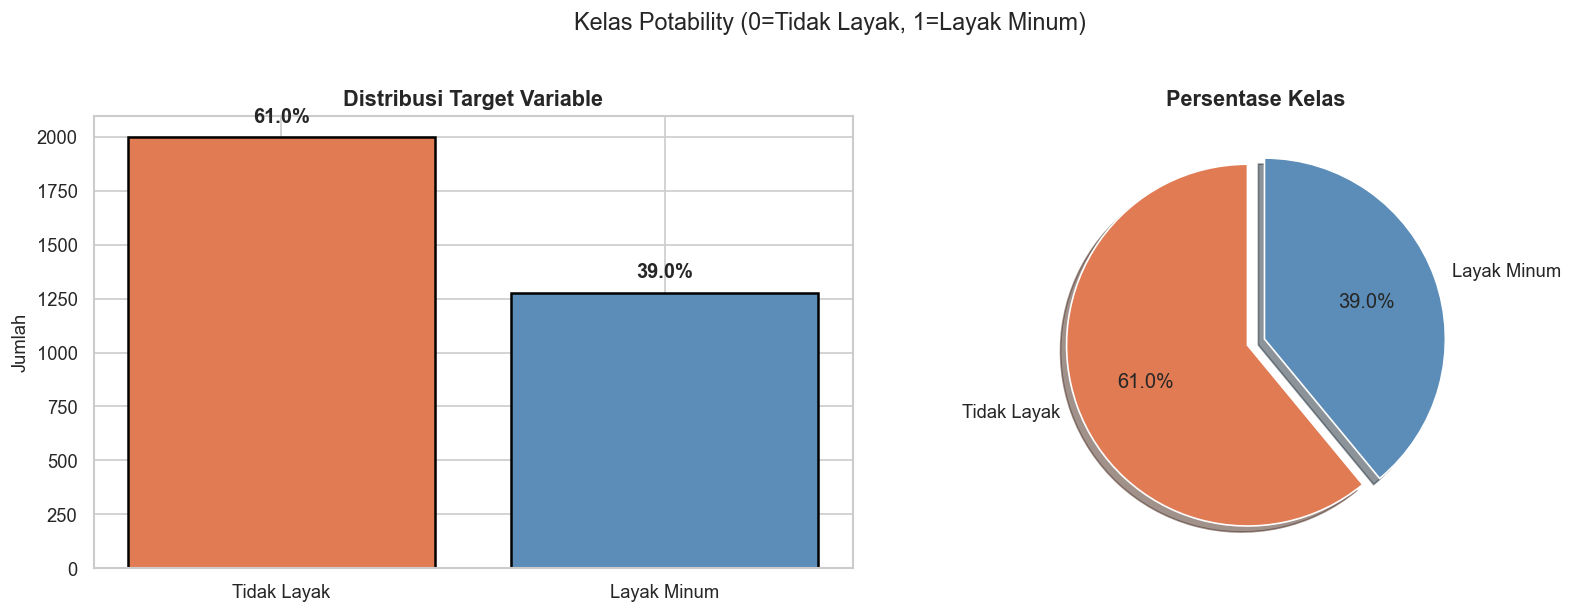

Kelas 0 (Tidak Layak): 1998 sampel (61.0%)
Kelas 1 (Layak Minum): 1278 sampel (39.0%)

⚠️ Dataset tidak seimbang (imbalanced)


In [7]:
# 1. Distribusi Target Variable (Potability)
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Count plot
potability_counts = df['Potability'].value_counts()
bars = axes[0].bar(['Tidak Layak', 'Layak Minum'], potability_counts.values, 
                   color=['#e07b54', '#5b8db8'], edgecolor='black', linewidth=1.5)
axes[0].set_ylabel('Jumlah', fontsize=11)
axes[0].set_title('Distribusi Target Variable', fontsize=13, fontweight='bold')
axes[0].tick_params(axis='x', labelsize=11)

# Add percentage labels
total = len(df)
for i, (bar, count) in enumerate(zip(bars, potability_counts.values)):
    pct = (count / total) * 100
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 50, 
                 f'{pct:.1f}%', ha='center', va='bottom', fontsize=12, fontweight='bold')

# Pie chart
colors = ['#e07b54', '#5b8db8']
axes[1].pie(potability_counts.values, labels=['Tidak Layak', 'Layak Minum'], 
            autopct='%1.1f%%', colors=colors, startangle=90, 
            explode=(0.05, 0.05), shadow=True)
axes[1].set_title('Persentase Kelas', fontsize=13, fontweight='bold')

plt.suptitle('Kelas Potability (0=Tidak Layak, 1=Layak Minum)', fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

print(f"Kelas 0 (Tidak Layak): {potability_counts[0]} sampel ({potability_counts[0]/total*100:.1f}%)")
print(f"Kelas 1 (Layak Minum): {potability_counts[1]} sampel ({potability_counts[1]/total*100:.1f}%)")
print(f"\n⚠️ Dataset tidak seimbang (imbalanced)" if potability_counts[0] != potability_counts[1] else "✓ Dataset seimbang")

### 2. Visualisasi Missing Values

Pada bagian ini, kita akan menganalisis nilai yang hilang (*missing values*) dalam dataset:

**Dua jenis visualisasi yang digunakan:**
- **Heatmap**: Menampilkan pola distribusi missing values pada 500 sampel pertama
- **Bar Plot**: Menunjukkan persentase missing values pada setiap kolom fitur

**Kolom dengan missing values:**
- `ph`: ~15%
- `Sulfate`: ~24%
- `Trihalomethanes`: ~5%

Analisis ini penting untuk menentukan strategi penanganan missing values yang akan digunakan pada tahap preprocessing.

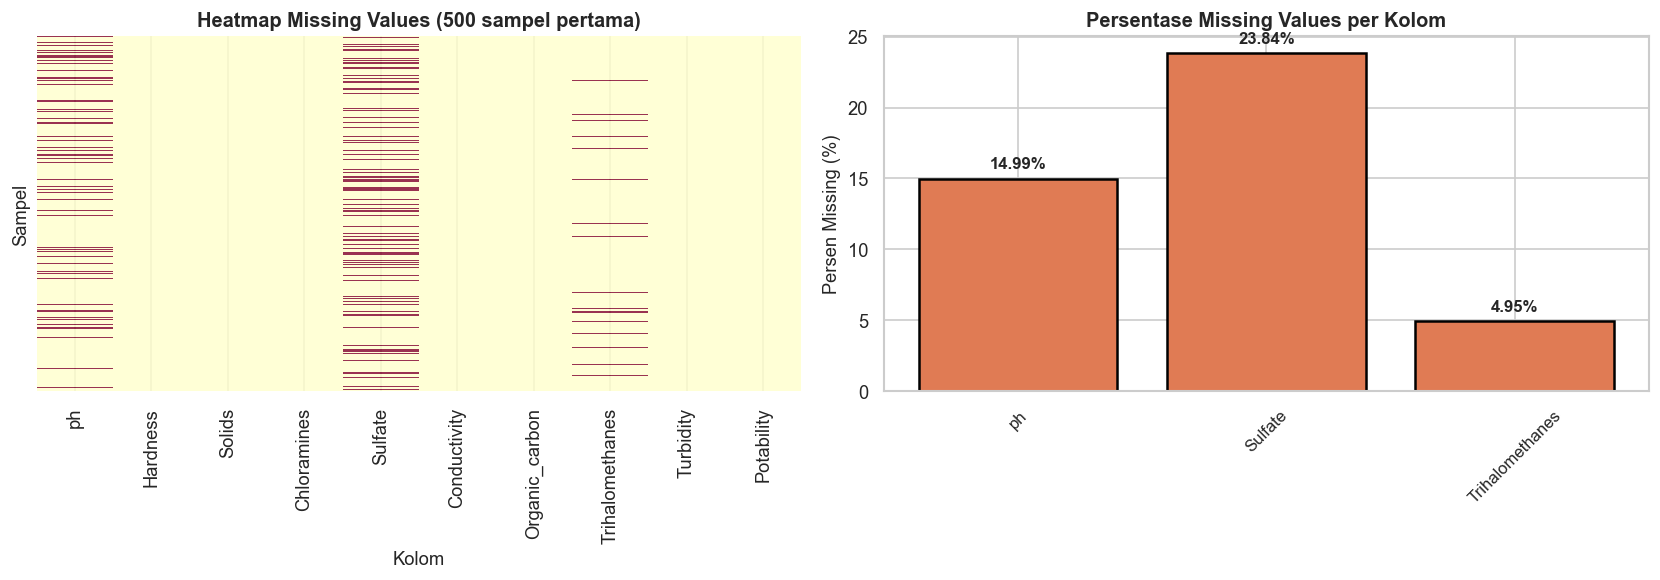


📊 Kolom dengan Missing Values:
  - ph: 491 (14.99%)
  - Sulfate: 781 (23.84%)
  - Trihalomethanes: 162 (4.95%)


In [8]:
# 2. Visualisasi Missing Values
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Heatmap missing values
missing_df = df.isnull()
sns.heatmap(missing_df.iloc[:500], cbar=False, ax=axes[0], 
            yticklabels=False, cmap='YlOrRd', alpha=0.8)
axes[0].set_title('Heatmap Missing Values (500 sampel pertama)', fontsize=12, fontweight='bold')
axes[0].set_xlabel('Kolom', fontsize=11)
axes[0].set_ylabel('Sampel', fontsize=11)

# Bar plot missing values per kolom
missing_per_col = df.isnull().sum()
missing_pct = (missing_per_col / len(df) * 100).round(2)
missing_df_plot = pd.DataFrame({'Kolom': missing_per_col.index, 'Missing': missing_per_col.values, 'Persen': missing_pct})
missing_df_plot = missing_df_plot[missing_df_plot['Missing'] > 0]

if len(missing_df_plot) > 0:
    bars = axes[1].bar(missing_df_plot['Kolom'], missing_df_plot['Persen'], 
                       color='#e07b54', edgecolor='black', linewidth=1.5)
    axes[1].set_ylabel('Persen Missing (%)', fontsize=11)
    axes[1].set_title('Persentase Missing Values per Kolom', fontsize=12, fontweight='bold')
    axes[1].tick_params(axis='x', rotation=45, labelsize=10)
    
    # Add value labels
    for bar, pct in zip(bars, missing_df_plot['Persen']):
        axes[1].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5,
                    f'{pct}%', ha='center', va='bottom', fontsize=10, fontweight='bold')
else:
    axes[1].text(0.5, 0.5, 'Tidak ada missing values', ha='center', va='center', 
                transform=axes[1].transAxes, fontsize=14)
    axes[1].set_title('Missing Values per Kolom', fontsize=12, fontweight='bold')

plt.tight_layout()
plt.show()

print("\n📊 Kolom dengan Missing Values:")
for col in missing_df_plot['Kolom']:
    print(f"  - {col}: {missing_per_col[col]} ({missing_pct[col]}%)")

### 3. Distribusi Fitur Numerik

Pada bagian ini, kita akan memvisualisasikan distribusi setiap fitur numerik menggunakan histogram dengan KDE (*Kernel Density Estimation*):

**Tujuan analisis:**
- Memahami pola distribusi data pada setiap parameter kualitas air
- Mengidentifikasi adanya *skewness* (kemencengan distribusi)
- Mendeteksi kemungkinan anomali atau nilai ekstrem

**Fitur yang dianalisis:**
- `ph`, `Hardness`, `Solids`, `Chloramines`, `Sulfate`
- `Conductivity`, `Organic_carbon`, `Trihalomethanes`, `Turbidity`

Analisis ini membantu memahami karakteristik data sebelum dilakukan preprocessing.

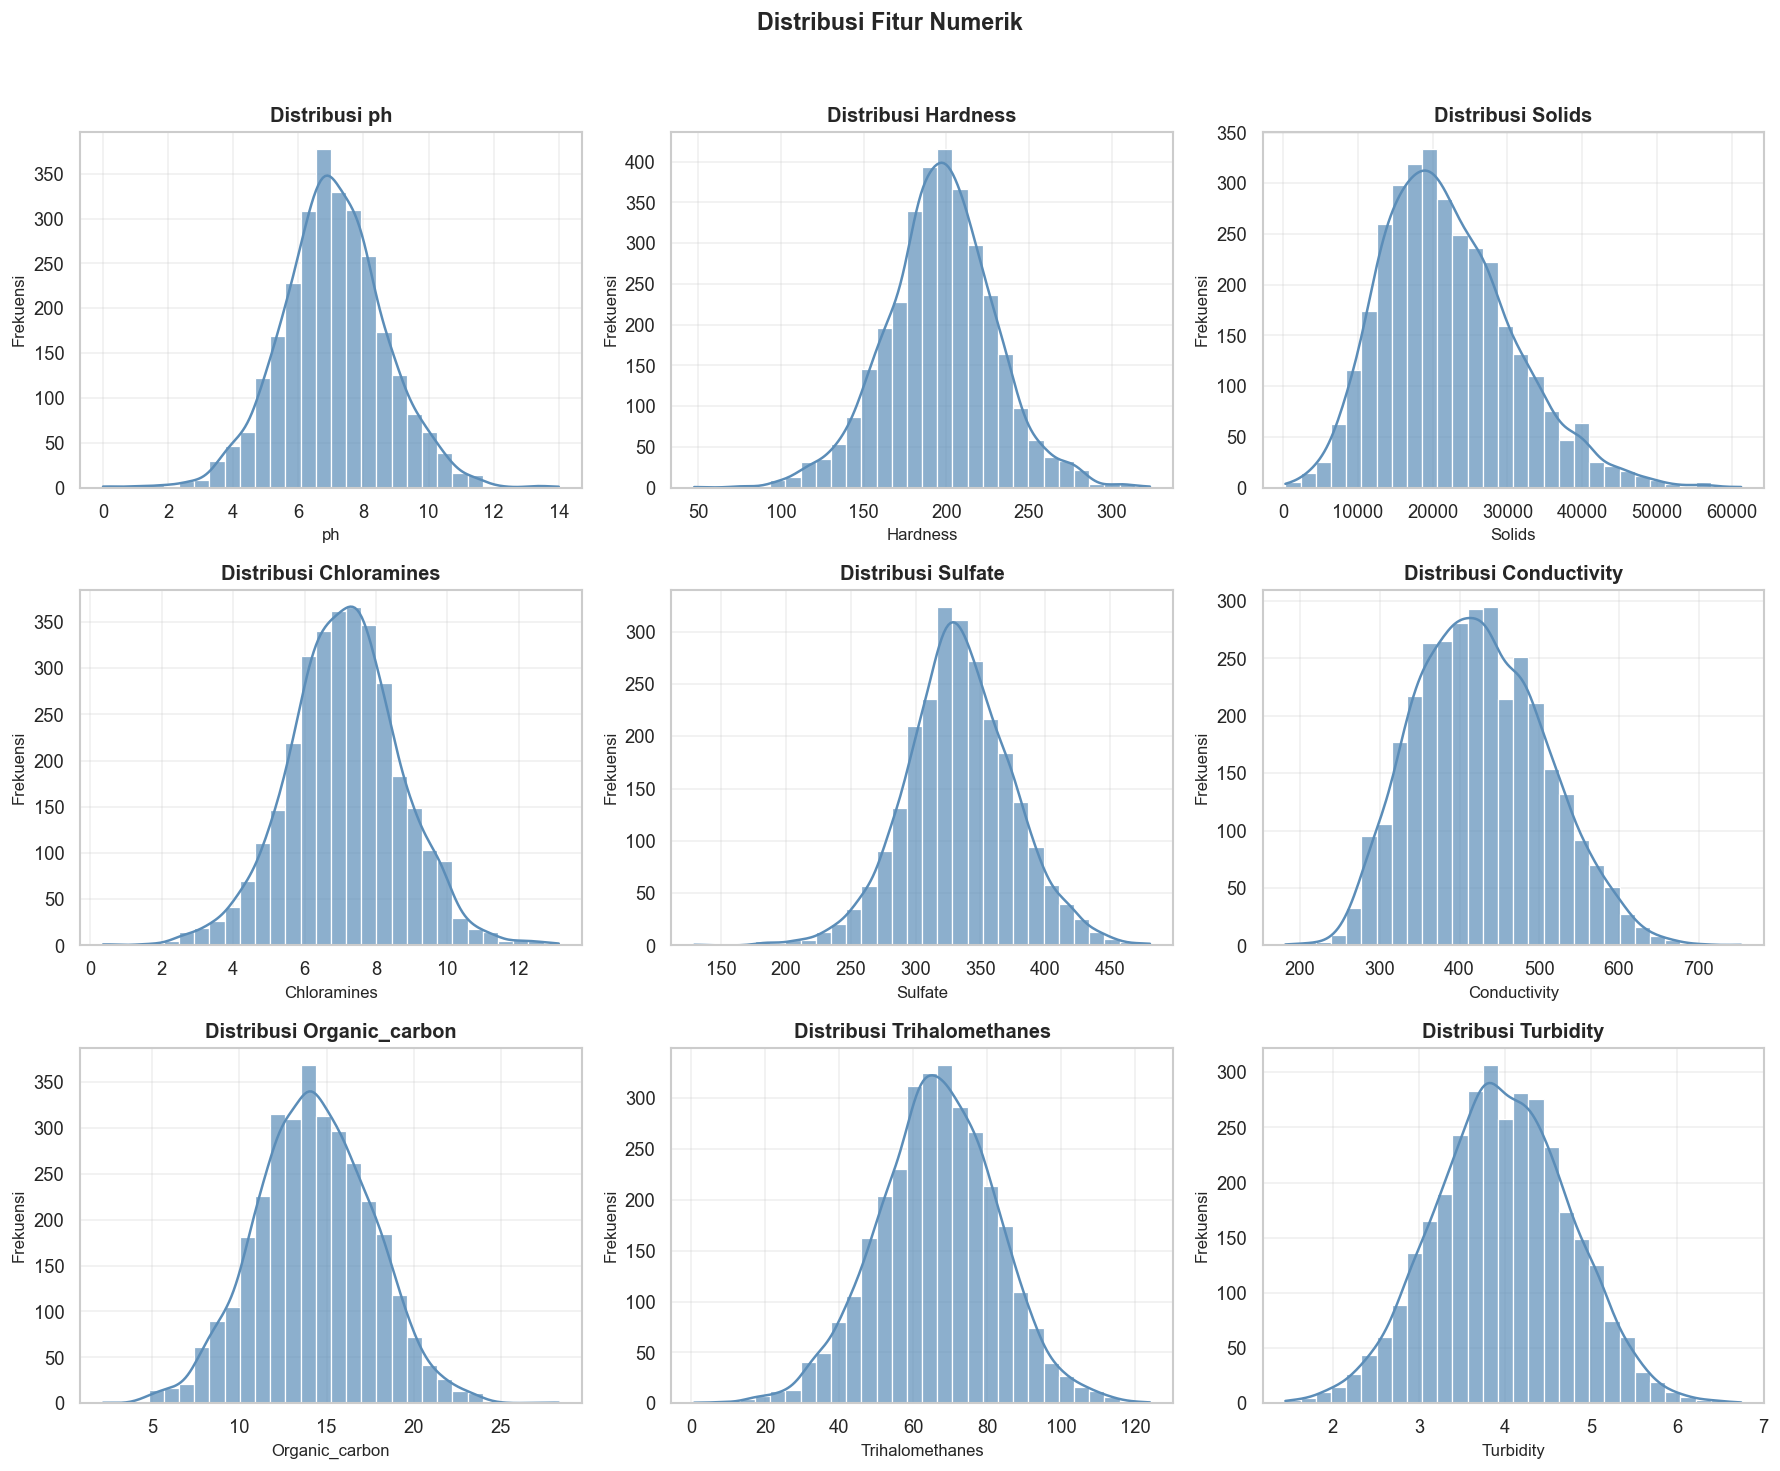

In [9]:
# 3. Distribusi Fitur Numerik
features = ['ph', 'Hardness', 'Solids', 'Chloramines', 'Sulfate', 
            'Conductivity', 'Organic_carbon', 'Trihalomethanes', 'Turbidity']

fig, axes = plt.subplots(3, 3, figsize=(15, 12))
axes = axes.flatten()

for i, feature in enumerate(features):
    # Histogram + KDE
    sns.histplot(data=df, x=feature, kde=True, ax=axes[i], 
                 color='#5b8db8', alpha=0.7, bins=30)
    axes[i].set_title(f'Distribusi {feature}', fontsize=12, fontweight='bold')
    axes[i].set_xlabel(feature, fontsize=10)
    axes[i].set_ylabel('Frekuensi', fontsize=10)
    axes[i].grid(True, alpha=0.3)

plt.suptitle('Distribusi Fitur Numerik', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

### 4. Deteksi Outlier dengan Boxplot

Pada bagian ini, kita akan menggunakan boxplot untuk mengidentifikasi keberadaan *outlier* pada setiap fitur numerik:

**Komponen utama boxplot:**
- **Box (Kotak)**: Rentang *Interquartile Range* (IQR) dari Q1 hingga Q3
- **Garis tengah**: Nilai median
- **Whisker**: Batas 1.5 × IQR
- **Titik di luar whisker**: Kandidat outlier

Deteksi outlier penting karena nilai ekstrem dapat mempengaruhi performa model machine learning dan menyebabkan bias dalam pelatihan model.

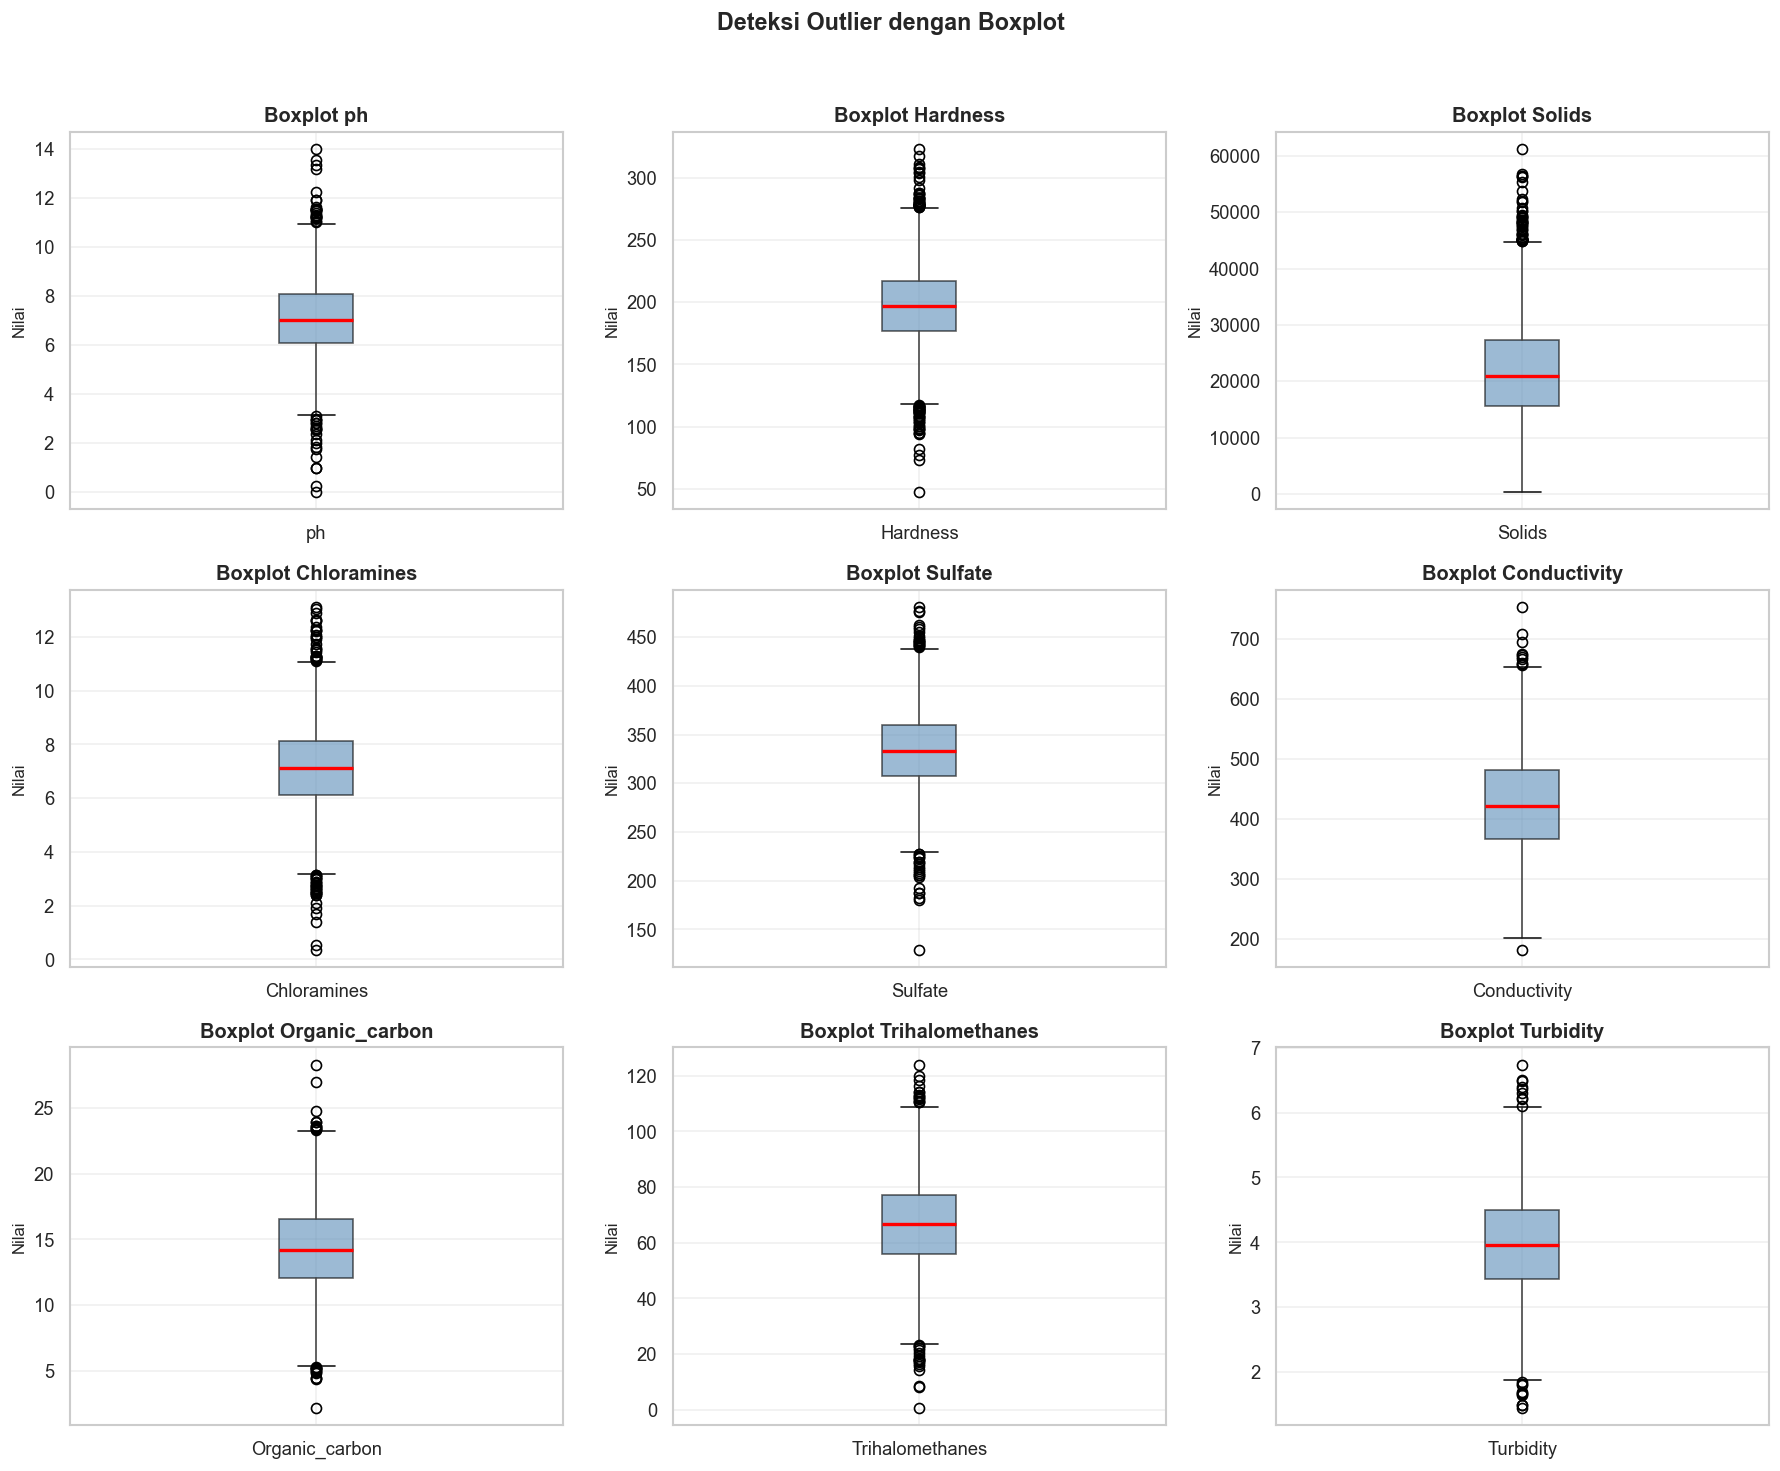


🔴 Titik di luar whisker boxplot adalah potential outliers


In [10]:
# 4. Boxplot untuk Deteksi Outlier
fig, axes = plt.subplots(3, 3, figsize=(15, 12))
axes = axes.flatten()

for i, feature in enumerate(features):
    df.boxplot(column=feature, ax=axes[i], patch_artist=True,
               boxprops=dict(facecolor='#5b8db8', alpha=0.6),
               medianprops=dict(color='red', linewidth=2))
    axes[i].set_title(f'Boxplot {feature}', fontsize=12, fontweight='bold')
    axes[i].set_ylabel('Nilai', fontsize=10)
    axes[i].grid(True, alpha=0.3)

plt.suptitle('Deteksi Outlier dengan Boxplot', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

print("\n🔴 Titik di luar whisker boxplot adalah potential outliers")

### 5. Korelasi Antar Fitur

Pada bagian ini, kita akan menganalisis hubungan linear antar fitur menggunakan *heatmap correlation*:

**Informasi yang didapat dari heatmap:**
- Kekuatan hubungan linear antar fitur (nilai -1 hingga +1)
- Fitur dengan korelasi tinggi yang berpotensi menyebabkan multikolinearitas
- Hubungan antara fitur dengan variabel target untuk identifikasi fitur prediktif

**Catatan:** Segitiga atas matriks korelasi di-*mask* (disembunyikan) untuk mempermudah interpretasi.

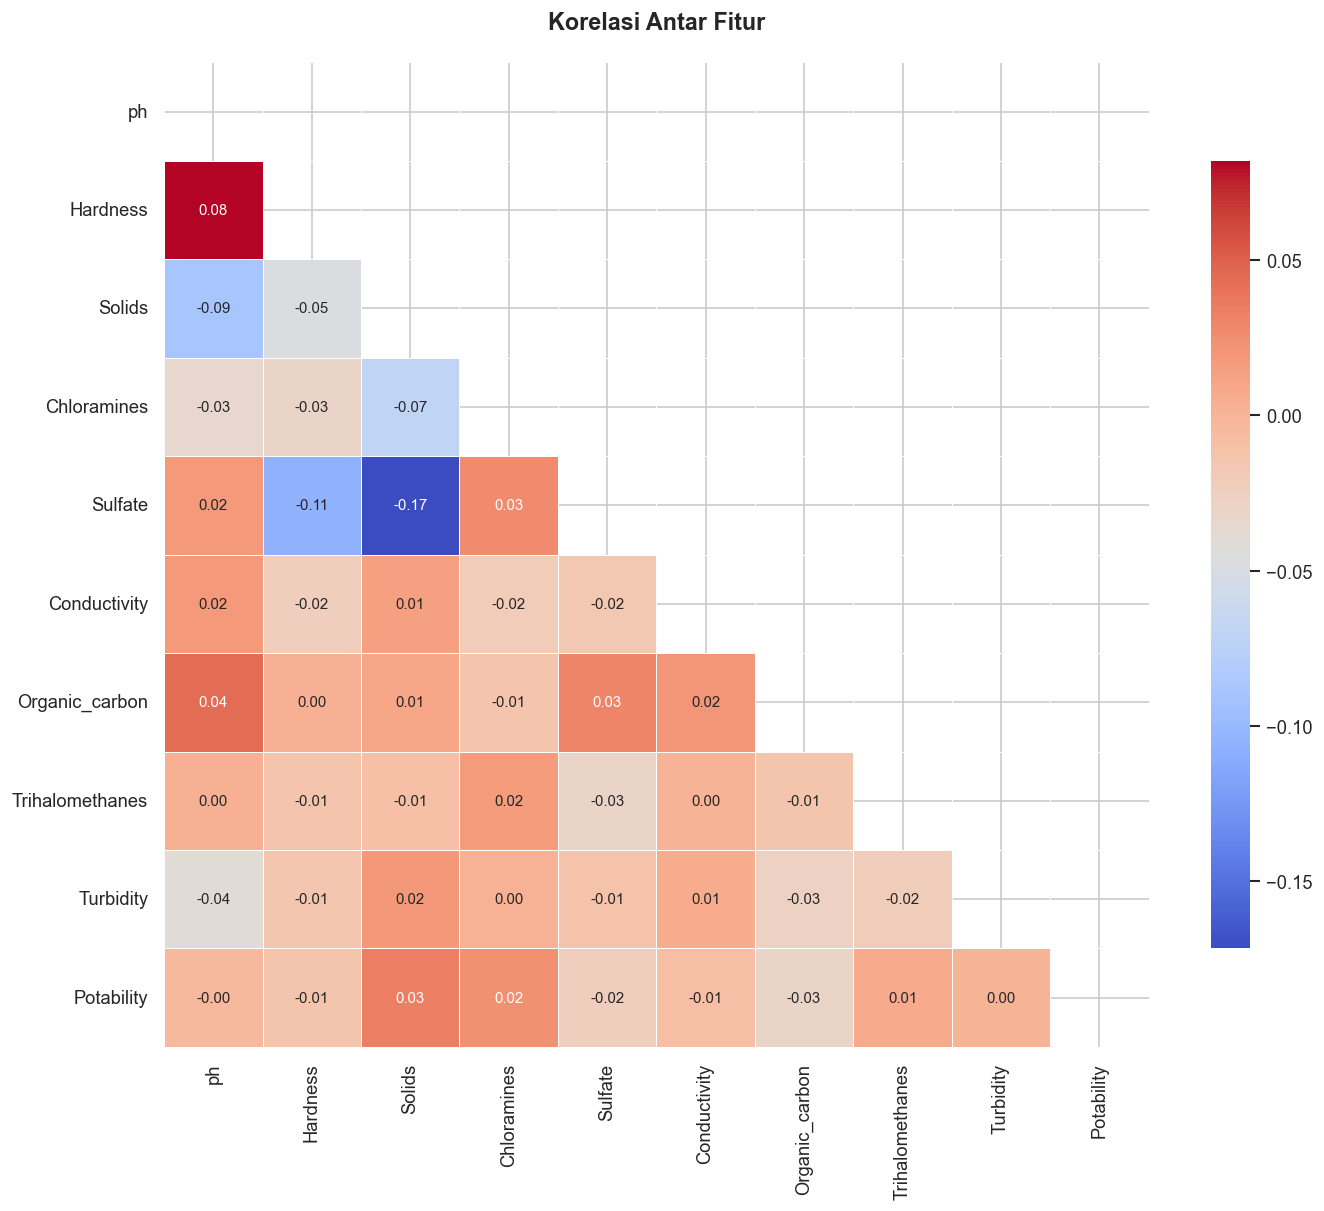


📊 Korelasi Fitur dengan Target (Potability):
  - Solids: 0.034
  - Organic_carbon: 0.030
  - Chloramines: 0.024
  - Sulfate: 0.024
  - Hardness: 0.014
  - Conductivity: 0.008
  - Trihalomethanes: 0.007
  - ph: 0.004
  - Turbidity: 0.002


In [11]:
# 5. Korelasi Antar Fitur
plt.figure(figsize=(12, 10))
corr_matrix = df[features + ['Potability']].corr()
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))

sns.heatmap(corr_matrix, mask=mask, annot=True, fmt='.2f', cmap='coolwarm',
            square=True, linewidths=0.5, cbar_kws={'shrink': 0.8},
            annot_kws={'size': 9})
plt.title('Korelasi Antar Fitur', fontsize=14, fontweight='bold', pad=20)
plt.tight_layout()
plt.show()

# Korelasi dengan target
print("\n📊 Korelasi Fitur dengan Target (Potability):")
corr_with_target = corr_matrix['Potability'].drop('Potability').abs().sort_values(ascending=False)
for feat, corr in corr_with_target.items():
    print(f"  - {feat}: {corr:.3f}")

<div style="background-color:#d40457; padding:15px; border-radius:10px;">
    <h1 style="color:white; margin:0;">Preprocessing</h1>
</div>

### 1. Memisahkan Features dan Target

Pada bagian ini, dataset dipisahkan menjadi dua bagian:

**Komponen dataset:**
- **X (Features)**: Seluruh kolom fitur selain `Potability`
- **y (Target)**: Kolom `Potability`

**Tujuan pemisahan:**
- Model machine learning membutuhkan input (X) dan output (y) yang terpisah
- Memungkinkan evaluasi performa model pada data test

In [12]:
# 1. Memisahkan Features (X) dan Target (y)
X = df.drop('Potability', axis=1)
y = df['Potability']

print(f"Features (X): {X.shape}")
print(f"Target (y): {y.shape}")

Features (X): (3276, 9)
Target (y): (3276,)


### 2. Train-Test Split (80% : 20%)

Pada bagian ini, dataset dibagi menjadi dua subset:

**Pembagian data:**
- **Training set (80%)**: Digunakan untuk melatih model
- **Test set (20%)**: Digunakan untuk mengevaluasi performa model

**Parameter penting:**
- `stratify=y`: Memastikan proporsi kelas pada training dan test set tetap sama
- `random_state=RANDOM_STATE`: Memastikan hasil yang konsisten (reproducible)

**Catatan:** Stratifikasi sangat penting untuk dataset dengan *class imbalance*.

In [13]:
# 2. Split Data: Train-Test (80-20)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=RANDOM_STATE, stratify=y
)

print(f"X_train: {X_train.shape}")
print(f"X_test: {X_test.shape}")
print(f"y_train: {y_train.shape}")
print(f"y_test: {y_test.shape}")

print(f"\nDistribusi kelas di data train:\n{y_train.value_counts(normalize=True)*100}")
print(f"\nDistribusi kelas di data test:\n{y_test.value_counts(normalize=True)*100}")

X_train: (2620, 9)
X_test: (656, 9)
y_train: (2620,)
y_test: (656,)

Distribusi kelas di data train:
Potability
0   60.9924
1   39.0076
Name: proportion, dtype: float64

Distribusi kelas di data test:
Potability
0   60.9756
1   39.0244
Name: proportion, dtype: float64


### 3. Handling Missing Values – Imputasi

Pada bagian ini, nilai yang hilang (*missing values*) ditangani menggunakan metode **imputasi median**:

**Alasan penggunaan median:**
- Lebih *robust* terhadap outlier dibandingkan dengan mean
- Tidak terlalu dipengaruhi oleh nilai ekstrem

**Proses imputasi:**
- Menggunakan `SimpleImputer` dengan `strategy='median'`
- Imputer di-fit pada **training data** saja
- Parameter yang diperoleh digunakan untuk mentransformasi training dan test data

**Penting:** Pendekatan ini mencegah *data leakage* (informasi dari test set tidak bocor ke training set).

In [14]:
# 3. Handling Missing Values dengan Imputasi
# Menggunakan median karena RobustScaler akan digunakan (tahan terhadap outlier)
imputer = SimpleImputer(strategy='median')

# Fit imputer pada data train, transform pada train dan test
X_train_imputed = imputer.fit_transform(X_train)
X_test_imputed = imputer.transform(X_test)

# Convert back to DataFrame untuk interpretasi
X_train_imputed = pd.DataFrame(X_train_imputed, columns=X.columns, index=X_train.index)
X_test_imputed = pd.DataFrame(X_test_imputed, columns=X.columns, index=X_test.index)

print("✓ Missing values telah diimputasi dengan median")
print(f"  Total missing values setelah imputasi: {X_train_imputed.isnull().sum().sum() + X_test_imputed.isnull().sum().sum()}")

✓ Missing values telah diimputasi dengan median
  Total missing values setelah imputasi: 0


### 4. Feature Scaling dengan RobustScaler

Pada tahap ini, dilakukan proses **feature scaling** untuk menyamakan skala antar fitur menggunakan metode **RobustScaler**.

**Karakteristik RobustScaler:**
- Menggunakan **median** sebagai pusat data
- Menggunakan **IQR (Interquartile Range)** sebagai skala
- Lebih *robust* terhadap **outlier** dibandingkan metode scaling lain seperti StandardScaler atau MinMaxScaler

**Scaling penting terutama untuk algoritma yang sensitif terhadap skala fitur, seperti:**
- **Support Vector Machine (SVM)**
- **K-Nearest Neighbors (KNN)**
- **Neural Networks**

**Proses scaling:**
- Menggunakan `RobustScaler` dari `sklearn.preprocessing`
- Scaler di-fit pada **training data** saja
- Parameter yang diperoleh kemudian digunakan untuk mentransformasi **training dan test data**

**Penting:** Pendekatan ini dilakukan untuk mencegah *data leakage*, yaitu kondisi ketika informasi dari test set secara tidak sengaja digunakan dalam proses training model.

In [15]:
# 4. Feature Scaling dengan RobustScaler
# RobustScaler cocok untuk data dengan outlier
scaler = RobustScaler()

# Fit scaler pada data train, transform pada train dan test
X_train_scaled = scaler.fit_transform(X_train_imputed)
X_test_scaled = scaler.transform(X_test_imputed)

# Convert back to DataFrame
X_train_scaled = pd.DataFrame(X_train_scaled, columns=X.columns, index=X_train.index)
X_test_scaled = pd.DataFrame(X_test_scaled, columns=X.columns, index=X_test.index)

print("✓ Feature scaling selesai dengan RobustScaler")
print(f"\nStatistik setelah scaling (data train):")
print(X_train_scaled.describe().round(2))

✓ Feature scaling selesai dengan RobustScaler

Statistik setelah scaling (data train):
             ph  Hardness    Solids  Chloramines   Sulfate  Conductivity  \
count 2620.0000 2620.0000 2620.0000    2620.0000 2620.0000     2620.0000   
mean     0.0300   -0.0100    0.0900      -0.0000    0.0200        0.0300   
std      0.9200    0.8300    0.7500       0.8000    1.1100        0.6900   
min     -4.2700   -3.8100   -1.7600      -3.4000   -6.2300       -2.0900   
25%     -0.4800   -0.5000   -0.4600      -0.5000   -0.4800       -0.4900   
50%      0.0000   -0.0000   -0.0000       0.0000    0.0000        0.0000   
75%      0.5200    0.5000    0.5400       0.5000    0.5200        0.5100   
max      4.0800    3.2200    3.4700       2.9800    4.5200        2.8100   

       Organic_carbon  Trihalomethanes  Turbidity  
count       2620.0000        2620.0000  2620.0000  
mean           0.0100          -0.0200     0.0000  
std            0.7300           0.7900     0.7400  
min           -2.680

### 5. Visualisasi Sebelum dan Sesudah Scaling

Pada bagian ini dilakukan visualisasi untuk membandingkan distribusi fitur sebelum dan sesudah proses **feature scaling**.

Visualisasi ini bertujuan untuk melihat bagaimana proses scaling mempengaruhi skala data tanpa mengubah pola distribusinya.

**Perbandingan hasil visualisasi:**

- **Data asli (Original):**
  - Memiliki skala yang berbeda-beda antar fitur
  - Beberapa fitur memiliki nilai yang jauh lebih besar dibanding fitur lainnya

- **Data setelah scaling (Scaled):**
  - Median mendekati **0**
  - **Interquartile Range (IQR)** mendekati **1**

**Kesimpulan:**

Hasil visualisasi menunjukkan bahwa proses **scaling berhasil menstandardisasi skala fitur**, sehingga semua fitur berada pada rentang yang lebih seragam tanpa mengubah bentuk distribusi data.

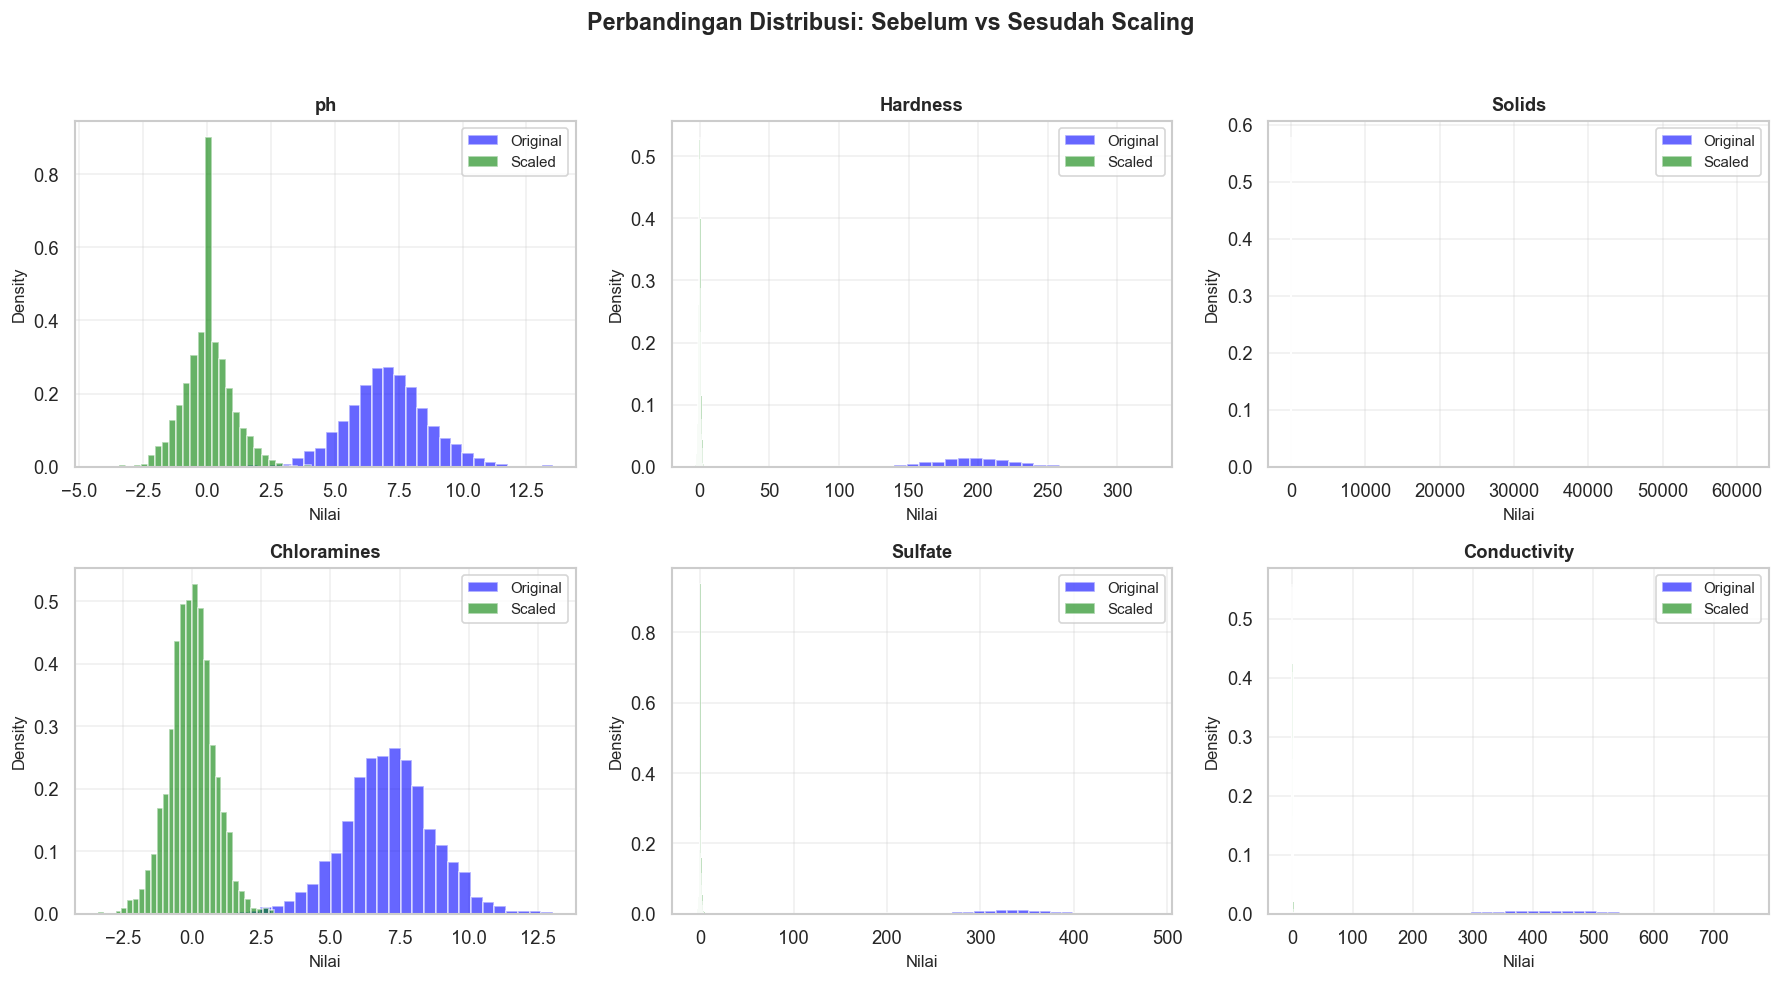

In [16]:
# 5. Visualisasi: Sebelum vs Sesudah Scaling
fig, axes = plt.subplots(2, 3, figsize=(15, 8))
axes = axes.flatten()

sample_features = ['ph', 'Hardness', 'Solids', 'Chloramines', 'Sulfate', 'Conductivity']

for i, feature in enumerate(sample_features):
    # Sebelum scaling (original)
    axes[i].hist(X_train[feature].dropna(), bins=30, alpha=0.6, color='blue', 
                 label='Original', density=True)
    # Sesudah scaling
    axes[i].hist(X_train_scaled[feature], bins=30, alpha=0.6, color='green', 
                 label='Scaled', density=True)
    axes[i].set_title(f'{feature}', fontsize=11, fontweight='bold')
    axes[i].set_xlabel('Nilai', fontsize=10)
    axes[i].set_ylabel('Density', fontsize=10)
    axes[i].legend(loc='upper right', fontsize=9)
    axes[i].grid(True, alpha=0.3)

plt.suptitle('Perbandingan Distribusi: Sebelum vs Sesudah Scaling', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()